## Video Simulation Process

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
H, W, T = 100, 100, 300
# Objects
# object 1
obj1_size = 10
# object 2
obj2_radius = 6
obj2_intensity = 0.7
# object 3
obj3_size = 18
# Generate dynamic low-rank background
np.random.seed(1)
B0 = np.random.uniform(0,1,(H,W))
B1 = np.random.randn(H,W)
B1 = B1 / np.linalg.norm(B1)
B2 = np.random.randn(H,W)
B2 = B2 / np.linalg.norm(B2)
background_video = np.zeros((T,H,W))
for t in range(T):
    background_video[t] = (B0+0.20*np.sin(2*np.pi*t/80)*B1+0.15*np.cos(2*np.pi*t/120)*B2)
background_video = np.clip(background_video,0,1)

# Initialize video
video = np.zeros((T,H,W))
# Object functions
def add_object1(img,x,y):
    x=int(x)
    y=int(y)
    x2=x+obj1_size
    y2=y+obj1_size
    if x2<=0 or y2<=0 or x>=W or y>=H:
        return
    x1=max(x,0)
    y1=max(y,0)
    x2=min(x2,W)
    y2=min(y2,H)
    img[y1:y2,x1:x2]=0
    # white corners
    corners=[(x,y),(x+obj1_size-1,y),(x,y+obj1_size-1),(x+obj1_size-1,y+obj1_size-1)]
    for cx,cy in corners:
        if 0<=cx<W and 0<=cy<H:
            img[cy,cx]=1
    # plus sign
    cx=x+obj1_size//2
    cy=y+obj1_size//2
    for dx in range(-2,3):
        if 0<=cx+dx<W and 0<=cy<H:
            img[cy,cx+dx]=1
    for dy in range(-2,3):
        if 0<=cx<W and 0<=cy+dy<H:
            img[cy+dy,cx]=1

def add_object2(img,x,y):
    x=int(x)
    y=int(y)
    for i in range(-obj2_radius,obj2_radius+1):
        for j in range(-obj2_radius,obj2_radius+1):
            if i*i+j*j<=obj2_radius**2:
                nx=x+j
                ny=y+i
                if 0<=nx<W and 0<=ny<H:
                    img[ny,nx]=obj2_intensity

def add_object3(img,x,y):
    x=int(x)
    y=int(y)
    x2=x+obj3_size
    y2=y+obj3_size
    if x2<=0 or y2<=0 or x>=W or y>=H:
        return
    # border
    for i in range(obj3_size):
        xx=x+i
        if 0<=xx<W:
            if 0<=y<H:
                img[y,xx]=0
            if 0<=y2-1<H:
                img[y2-1,xx]=0
    for j in range(obj3_size):
        yy=y+j
        if 0<=yy<H:
            if 0<=x<W:
                img[yy,x]=0
            if 0<=x2-1<W:
                img[yy,x2-1]=0
    # X
    for i in range(obj3_size):
        xx=x+i
        yy1=y+i
        yy2=y+obj3_size-1-i
        if 0<=xx<W:
            if 0<=yy1<H:
                img[yy1,xx]=0
            if 0<=yy2<H:
                img[yy2,xx]=0

# Motion trajectories
# object 1
pos1_x=np.zeros(T)
pos1_y=np.zeros(T)
perimeter=2*(H+W)-4
speed1=3
for t in range(T):
    s=(t*speed1)%perimeter
    if s<W:
        pos1_x[t]=s
        pos1_y[t]=0
    elif s<W+H-1:
        pos1_x[t]=W-1
        pos1_y[t]=s-W+1
    elif s<2*W+H-2:
        pos1_x[t]=2*W+H-3-s
        pos1_y[t]=H-1
    else:
        pos1_x[t]=0
        pos1_y[t]=2*W+2*H-4-s
# ---------------- object 2 ----------------
pos2_x=np.zeros(T)
pos2_y=np.zeros(T)
vx2=-1.5
vy2=-2.5
pos2_x[24]=10
pos2_y[24]=70
for t in range(25,T):
    pos2_x[t]=pos2_x[t-1]+vx2
    pos2_y[t]=pos2_y[t-1]+vy2
    if pos2_x[t]<0 or pos2_x[t]>W:
        vx2=-vx2
    if pos2_y[t]<20 or pos2_y[t]>H:
        vy2=-vy2
# ---------------- object 3 ----------------
pos3_x=np.zeros(T)
pos3_y=np.zeros(T)
vx3=-4
vy3=1
ax3=0.03
pos3_x[49]=W-obj3_size
pos3_y[49]=20

for t in range(50,T):
    vx3 += ax3
    pos3_x[t]=pos3_x[t-1]+vx3
    pos3_y[t]=pos3_y[t-1]+vy3
    if pos3_x[t]<0 or pos3_x[t]+obj3_size>W:
        vx3=-vx3
        pos3_x[t]=np.clip(pos3_x[t], 0, W-obj3_size)
    if pos3_y[t]<0 or pos3_y[t]+obj3_size>H:
        vy3=-vy3

# Construct video
for t in range(T):
    frame=background_video[t].copy()
    # draw order
    add_object1(frame,pos1_x[t],pos1_y[t])
    if t>=25:
        add_object2(frame,pos2_x[t],pos2_y[t])
    if t>=50:
        add_object3(frame,pos3_x[t],pos3_y[t])
    video[t]=frame
    
# Ground truth
bg_true=background_video.copy()
fg_true=video-bg_true

# Save
np.save("synthetic_video.npy",video)
np.save("synthetic_background.npy",background_video)
np.save("synthetic_bg_true.npy",bg_true)
np.save("synthetic_fg_true.npy",fg_true)

print("video shape :",video.shape)
print("bg shape    :",bg_true.shape)
print("fg shape    :",fg_true.shape)


video shape : (300, 100, 100)
bg shape    : (300, 100, 100)
fg shape    : (300, 100, 100)


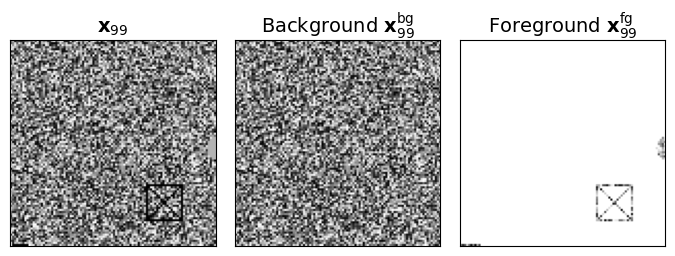

In [2]:
t = 99
bg = bg_true[t]
fg = fg_true[t]
observed = video[t]
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

im0 = axes[0].imshow(observed, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(r"$\mathbf{x}_{99}$", fontsize=14)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_aspect('equal')

im1 = axes[1].imshow(bg, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(r"Background $\mathbf{x}_{99}^{\rm bg}$", fontsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_aspect('equal')

fg_abs = np.abs(fg)
fg_disp = np.clip(fg_abs, 0, 1)
im2 = axes[2].imshow(1 - fg_disp, cmap="gray", vmin=0, vmax=1)  # ✅ 改为 axes[2]
axes[2].set_title(r"Foreground $\mathbf{x}_{99}^{\rm fg}$", fontsize=14)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].set_aspect('equal')

plt.tight_layout()
plt.subplots_adjust(wspace=0.02)

# Simulation experiments

In [3]:
from pydmd import DMD
from sklearn.metrics import mean_squared_error

import STQP, _separation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

video = np.load("synthetic_video.npy")
background = np.load("synthetic_background.npy")
bg_true = np.load("synthetic_bg_true.npy")
fg_true = np.load("synthetic_fg_true.npy")

T, H, W = video.shape

print("Video shape      :", video.shape)
print("Background shape :", background.shape)
print("BG GT shape      :", bg_true.shape)
print("FG GT shape      :", fg_true.shape)

U = video.reshape(T, -1).T
print("Data matrix shape:", U.shape)
def relative_error(X_true, X_rec):
    return (np.linalg.norm(X_true - X_rec)/(np.linalg.norm(X_true) + 1e-12))
results = []

Video shape      : (300, 100, 100)
Background shape : (300, 100, 100)
BG GT shape      : (300, 100, 100)
FG GT shape      : (300, 100, 100)
Data matrix shape: (10000, 300)


In [4]:
AXIS_LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

In [5]:
# Freq-DMD
start_time = time.perf_counter()
exact_dmd = DMD(svd_rank=-1)
exact_dmd.fit(U)

fps = 25
dt = 1.0 / fps
fg_video_exact, bg_video_exact, n_bg = _separation.Frequency_Based_Separation(model=exact_dmd,m=U.shape[1],
    H=H,W=W,U_full=U,dt=dt,omega_threshold=1e-2)

exact_time = time.perf_counter() - start_time

In [6]:
mus = [0.5,0.7,0.8,0.85, 1.0, 1.5, 2, 5]
rank = -1
stqp_list = {}
mu_results = []
for mu in mus:
    print(f"Running stqpDMD : mu = {mu}")
    model = STQP.stqpDMD(svd_rank=rank, mu=mu, tikhonov_regularization=0, 
                           use_csc=False, verbose=False).fit(U)
    stqp_list[f"mu_{mu}"] = model
    rec_mse = mean_squared_error( U, model.reconstructed_data.real)
    nnz = np.count_nonzero(np.abs(model._b) > 1e-12)
    mu_results.append([mu,rec_mse,nnz])
    print(f"MSE : {rec_mse:.6e}, nnz : {nnz}")

Running stqpDMD : mu = 0.5
MSE : 2.250389e-03, nnz : 183
Running stqpDMD : mu = 0.7
MSE : 3.777837e-03, nnz : 71
Running stqpDMD : mu = 0.8
MSE : 4.212154e-03, nnz : 57
Running stqpDMD : mu = 0.85
MSE : 4.302255e-03, nnz : 49
Running stqpDMD : mu = 1.0
MSE : 4.400931e-03, nnz : 43
Running stqpDMD : mu = 1.5
MSE : 5.725779e-03, nnz : 3
Running stqpDMD : mu = 2
MSE : 5.725779e-03, nnz : 3
Running stqpDMD : mu = 5
MSE : 5.725779e-03, nnz : 3


In [7]:
# STQP-DMD
start_time = time.perf_counter()
stqp_dmd = stqp_list["mu_1.0"]
fg_video_b, bg_video_b, n_bg, n_fg = _separation.STQP_Separation(model=stqp_dmd,
    m=U.shape[1],H=H,W=W,U_full=U)
runtime_b = time.perf_counter() - start_time

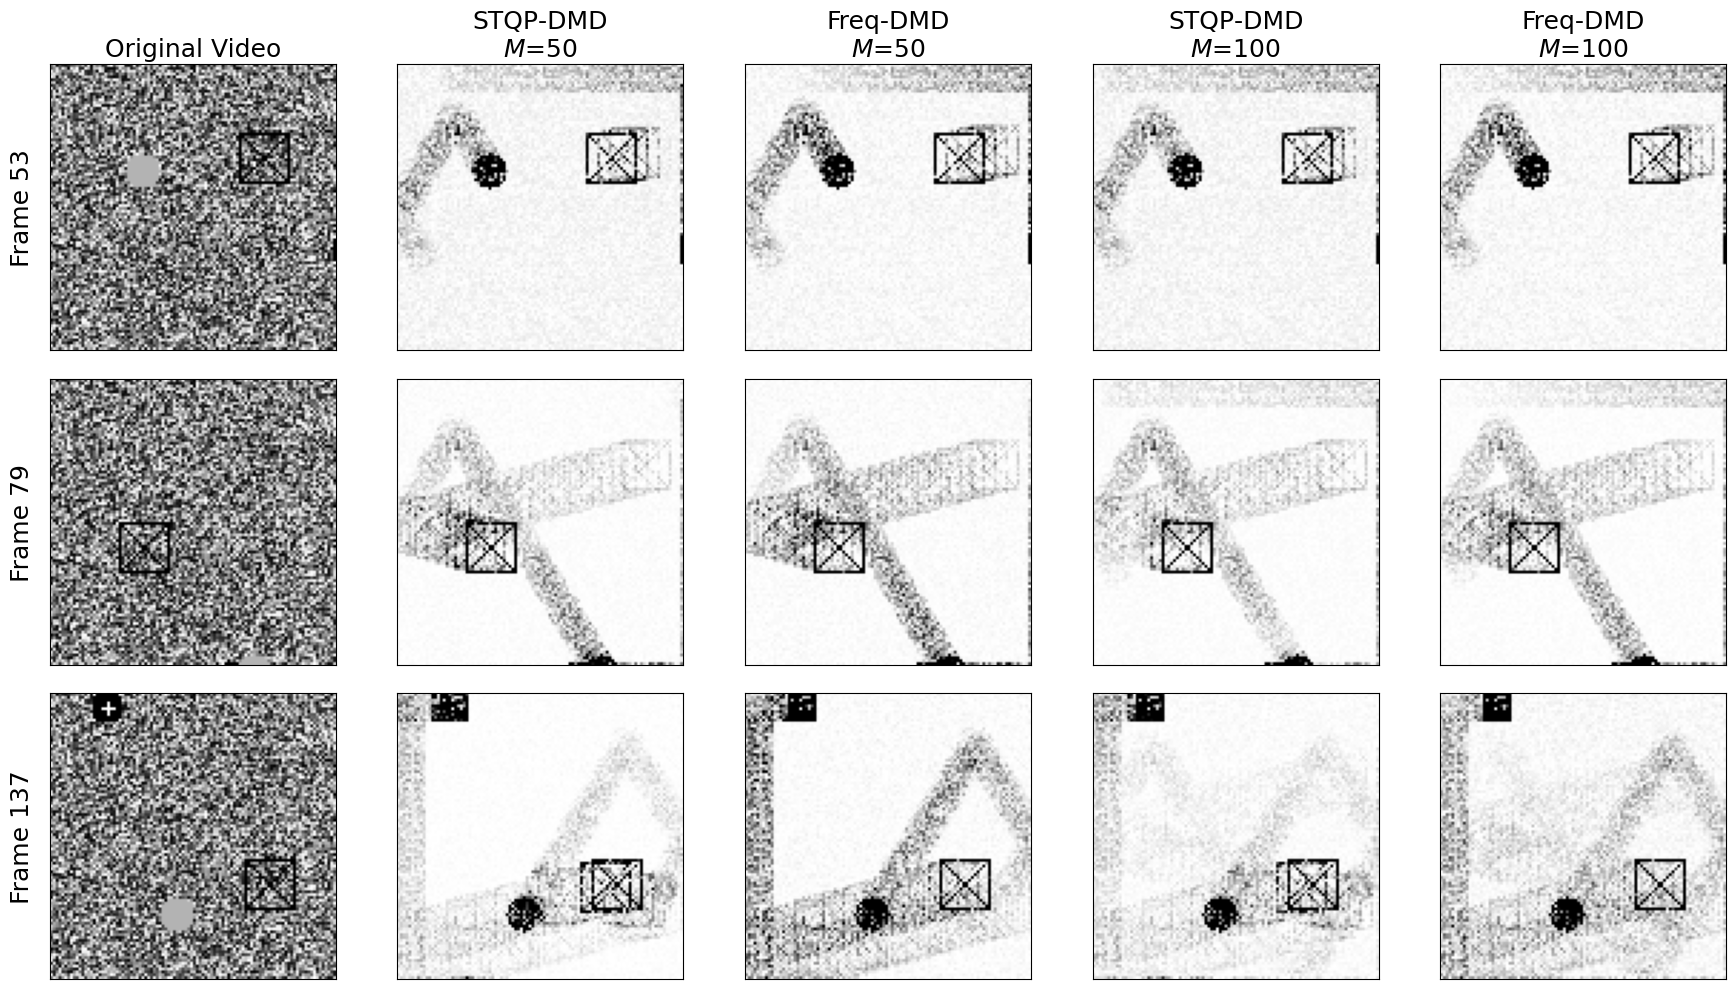

In [8]:
target_frames = [53, 79, 137]
segment_lengths = [50, 100]
fig, axes = plt.subplots(len(target_frames), len(segment_lengths) * 2 + 1, figsize=(18, 10))
fps = 25
dt = 1.0 / fps
for row, target_frame in enumerate(target_frames):
    axes[row, 0].imshow(video[target_frame], cmap="gray", vmin=0, vmax=1)
    if row == 0:
        axes[row, 0].set_title("Original Video", fontsize=AXIS_LABEL_SIZE+4)
    axes[row, 0].set_ylabel(f'Frame {target_frame}', rotation=90,
                            labelpad=20, ha='center', va='center', fontsize=AXIS_LABEL_SIZE+4)

    for col, m in enumerate(segment_lengths):
        start = max(0, target_frame - m + 1)
        end = target_frame + 1
        video_seg = video[start:end]
        m_actual = video_seg.shape[0]
        U_seg = (video_seg.reshape(m_actual, -1).T)

        # ========== STQP-DMD ==========
        model_stqp = STQP.stqpDMD(svd_rank=rank, mu=1.0,tikhonov_regularization=0, use_csc=False, verbose=False).fit(U_seg)
        Phi_stqp = model_stqp.modes
        eigs_stqp = model_stqp.eigs
        b_stqp = model_stqp._b
        b_abs = np.abs(b_stqp)
        idx = np.argsort(b_abs)[::-1]
        cum_b = (np.cumsum(b_abs[idx]) / np.sum(b_abs))
        k = (np.searchsorted(cum_b, 0.99) + 1)
        bg_modes_stqp = idx[:k]
        td_stqp = np.zeros((len(bg_modes_stqp), m_actual), dtype=complex)
        for i, mode_idx in enumerate(bg_modes_stqp):
            omega = np.log(eigs_stqp[mode_idx])
            td_stqp[i, :] = (b_stqp[mode_idx] * np.exp(omega * np.arange(m_actual)))
        X_bg_stqp = (Phi_stqp[:, bg_modes_stqp] @ td_stqp).real
        X_fg_stqp = U_seg - X_bg_stqp
        fg_video_stqp = (np.abs(X_fg_stqp).T.reshape(m_actual, H, W))
        fg_video_stqp = np.clip(fg_video_stqp * 10, 0, 1)
        
        col_idx = col * 2 + 1
        axes[row, col_idx].imshow(1 - fg_video_stqp[-1], cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row, col_idx].set_title(f"STQP‑DMD\n$M$={m}", fontsize=AXIS_LABEL_SIZE+4)

        # ========== Freq-DMD ==========
        model_dmd = DMD(svd_rank=rank).fit(U_seg)
        Phi_dmd = model_dmd.modes
        eigs_dmd = model_dmd.eigs
        b_dmd = model_dmd.amplitudes
        omega = np.log(eigs_dmd) / dt
        omega_threshold = 0.1
        bg_modes_dmd = np.where(np.abs(omega) < omega_threshold)[0]
        if len(bg_modes_dmd) == 0:
            idx = np.argsort(np.abs(omega))
            bg_modes_dmd = idx[:3]
        time_vec = np.arange(m_actual) * dt
        td_dmd = np.zeros((len(bg_modes_dmd), m_actual), dtype=complex)
        for i, mode_idx in enumerate(bg_modes_dmd):
            td_dmd[i, :] = (b_dmd[mode_idx] * np.exp(omega[mode_idx] * time_vec))
        X_bg_dmd = (Phi_dmd[:, bg_modes_dmd] @ td_dmd).real
        X_fg_dmd = U_seg - X_bg_dmd
        fg_video_dmd = np.abs(X_fg_dmd).T.reshape(m_actual, H, W)
        fg_video_dmd = np.clip(fg_video_dmd * 10, 0, 1)

        # Exact DMD列
        col_idx = col * 2 + 2
        axes[row, col_idx].imshow(1 - fg_video_dmd[-1], cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row, col_idx].set_title(f"Freq‑DMD\n$M$={m}", fontsize=AXIS_LABEL_SIZE+4)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)  
plt.show()


In [25]:
# Freq-DMD vs Amp-DMD vs RPCA
# Mean Normalized Background Pixel Brightness & Computational Time

segment_lengths = np.arange(10, 61, 5)
freq_err = []
amp_err = []
rpca_err = []
freq_time = []
amp_time = []
rpca_time = []

fps = 25
dt = 1.0 / fps

for m in segment_lengths:
    video_seg = video[:m]
    fg_true_seg = fg_true[:m]
    bg_true_seg = bg_true[:m]
    U_seg = video_seg.reshape(m, -1).T
    mask = (np.abs(fg_true_seg[:-1]) < 1e-12)
    # Freq-DMD
    t0 = time.perf_counter()
    model = DMD(svd_rank=rank).fit(U_seg)
    runtime = time.perf_counter() - t0
    fg_rec, bg_rec, n_bg = _separation.Frequency_Based_Separation(model=model,m=m,H=H,
        W=W,U_full=U_seg,dt=dt,omega_threshold=0.01)

    leakage = np.mean(np.abs(fg_rec[:-1][mask]))
    bg_intensity = np.mean(np.abs(bg_true_seg[:-1][mask]))
    err = leakage / bg_intensity
    freq_err.append(err)
    freq_time.append(runtime)

    # STQP-DMD
    t0 = time.perf_counter()
    stqp_model = STQP.stqpDMD(svd_rank=rank,mu=1,tikhonov_regularization=0,
                              use_csc=False,verbose=False).fit(U_seg)
    runtime = time.perf_counter() - t0

    fg_rec, bg_rec, n_bg, n_fg = _separation.STQP_Separation(model=stqp_model,m=m,H=H,W=W,U_full=U_seg)

    leakage = np.mean(np.abs(fg_rec[:-1][mask]))
    bg_intensity = np.mean(np.abs(bg_true_seg[:-1][mask]))
    err = leakage / bg_intensity
    amp_err.append(err)
    amp_time.append(runtime)

    # RPCA
    t0 = time.perf_counter()
    lam = 1 / np.sqrt(max(U_seg.shape))
    L, S = _separation.RPCA(U_seg, lam=lam, max_iter=1000, verbose=False)
    runtime = time.perf_counter() - t0

    fg_rec = np.abs(S).T.reshape(m, H, W)
    leakage = np.mean(np.abs(fg_rec[:-1][mask]))
    bg_intensity = np.mean(np.abs(bg_true_seg[:-1][mask]))
    err = leakage / bg_intensity
    rpca_err.append(err)
    rpca_time.append(runtime)

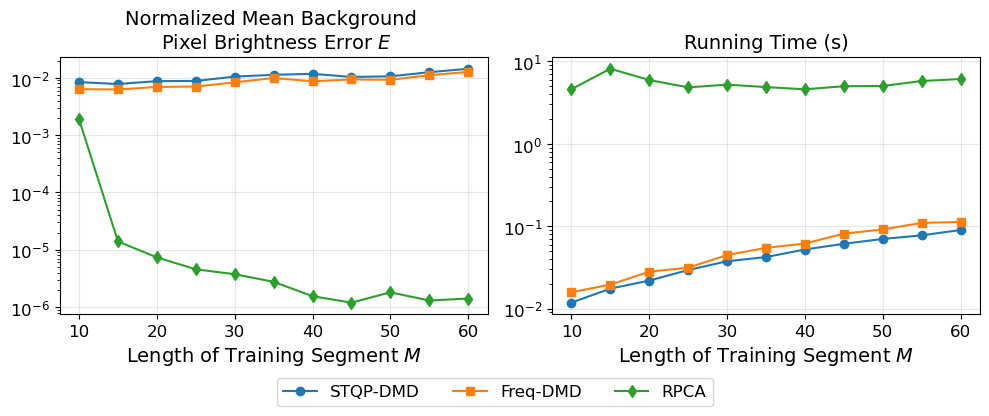

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
color1,color2,color3 = "#1f77b4","#ff7f0e","#2ca02c"

ax1.set_xlabel("Length of Training Segment $M$", fontsize=14)
l1, = ax1.plot(segment_lengths, freq_err, 'o-', color=color1, label="Freq-DMD")
l2, = ax1.plot(segment_lengths, amp_err, 's-', color=color2, label="STQP-DMD")
l3, = ax1.plot(segment_lengths, rpca_err, 'd-', color=color3, label="RPCA")
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid(alpha=0.3)
ax1.set_title("Normalized Mean Background \n Pixel Brightness Error $E$", fontsize=14)

ax2.set_xlabel("Length of Training Segment $M$", fontsize=14)
# ax2.set_ylabel("Running Time (s)", fontsize=12)
ax2.plot(segment_lengths, freq_time, 'o-', color=color1, label="Freq-DMD")
ax2.plot(segment_lengths, amp_time, 's-', color=color2, label="STQP-DMD")
ax2.plot(segment_lengths, rpca_time, 'd-', color=color3, label="RPCA")
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(alpha=0.3)
ax2.set_title("Running Time (s)", fontsize=14)

handles = [l1, l2, l3]
labels = ["STQP-DMD","Freq-DMD", "RPCA"]
fig.legend(handles, labels, ncol=3, fontsize=12, 
           loc='lower center', bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()